# Donor Churn Predictor
**Eban-Haven Platform — Donor Retention Pipeline**

| | |
|---|---|
| **Paradigm** | Predictive (binary classification) |
| **Business Question** | Which donors are most likely to go 12+ months without another gift? |
| **Primary Metrics** | ROC-AUC, F1, Precision, Recall |
| **Validation Strategy** | Train/test split + Stratified 5-fold CV + randomized search |
| **Deployment Artifact** | `ml-pipelines/donor_churn_model.joblib` |


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict, train_test_split

from retrain_donor_churn_model import (
    FEATURE_COLS,
    TARGET_HORIZON_DAYS,
    _load_data,
    build_historical_snapshots,
    build_preprocessor,
    candidate_search_spaces,
)

sns.set_theme(style="whitegrid")


## 1. Problem Framing

The organization depends on recurring donor support to keep safehouse operations stable, but staff do not have capacity to manually inspect every donor record for signs of lapse. This pipeline is therefore **predictive**, not explanatory: the goal is to score current donors by their risk of going quiet for roughly a year so fundraising staff can prioritize outreach.

### Why this target?
The older `supporters.status == Inactive` label was too tied to administrative definitions and too easy to contaminate with recency. The improved label is behavior-based:
- **Positive (1):** no new donation in the next `365` days after a historical observation snapshot
- **Negative (0):** at least one new donation within that horizon

That makes the modeling problem match the deployment question much more closely.


## 2. Data Acquisition, Preparation & Exploration

This notebook prefers the live Azure PostgreSQL database when `HAVEN_DB_CONN` is available. For offline reproducibility it falls back to the committed donor snapshots in:
- `backend/EbanHaven.Api/Data/lighthouse/supporters.csv`
- `backend/EbanHaven.Api/Data/lighthouse/donations.csv`

The key preparation step is building **historical donor snapshots**. Each row contains only information available at an observation date, then the donor is labeled by whether they donate again within the next 365 days. That censoring step is what prevents future leakage.


In [2]:
supporters, donations, data_source = _load_data()
df_model = build_historical_snapshots(supporters, donations, target_horizon_days=TARGET_HORIZON_DAYS)

print(f"Data source: {data_source}")
print(f"Snapshot rows: {len(df_model)}")
print(f"Positive rate: {df_model['target'].mean():.1%}")
print(df_model[FEATURE_COLS + ['target']].isna().mean().sort_values(ascending=False).head(10))
df_model.head(3)


Data source: csv_snapshot
Snapshot rows: 141
Positive rate: 19.1%
days_since_last_donation      0.0
days_since_first_donation     0.0
days_since_joined             0.0
total_donations               0.0
pct_recurring                 0.0
avg_days_between_donations    0.0
total_amount                  0.0
avg_amount                    0.0
max_amount                    0.0
amount_trend                  0.0
dtype: float64


/Users/lukecarr/Desktop/MassiveFolder/ml-pipelines/retrain_donor_churn_model.py:156: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  day_gaps = np.diff(pd.Series(observed_dates).view("int64")) / 86_400_000_000_000 if len(observed_dates) > 1 else []
/Users/lukecarr/Desktop/MassiveFolder/ml-pipelines/retrain_donor_churn_model.py:156: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  day_gaps = np.diff(pd.Series(observed_dates).view("int64")) / 86_400_000_000_000 if len(observed_dates) > 1 else []
/Users/lukecarr/Desktop/MassiveFolder/ml-pipelines/retrain_donor_churn_model.py:156: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  day_gaps = np.diff(pd.Series(observed_dates).view("int64")) / 86_400_000_000_000 if len(observed_da

,supporter_id,observation_date,target,days_since_last_donation,days_since_first_donation,days_since_joined,total_donations,pct_recurring,avg_days_between_donations,total_amount,avg_amount,max_amount,amount_trend,acquisition_channel,supporter_type,relationship_type
0,1,2023-03-25 00:00:00+00:00,0,0.0,0.0,448.0,1.0,1.0,0.0,774.61,774.610000,774.61,0.000,SocialMedia,SocialMediaAdvocate,Local
1,1,2023-07-01 00:00:00+00:00,0,0.0,98.0,546.0,2.0,1.0,98.0,1438.55,719.275000,774.61,-110.670,SocialMedia,SocialMediaAdvocate,Local
2,1,2023-12-20 00:00:00+00:00,0,0.0,270.0,718.0,3.0,1.0,135.0,4066.69,1355.563333,2628.14,926.765,SocialMedia,SocialMediaAdvocate,Local


,count,mean
supporter_type,,
InKindDonor,33,0.272727
SocialMediaAdvocate,21,0.238095
PartnerOrganization,9,0.222222
Volunteer,17,0.176471
MonetaryDonor,50,0.140000
SkillsContributor,11,0.090909


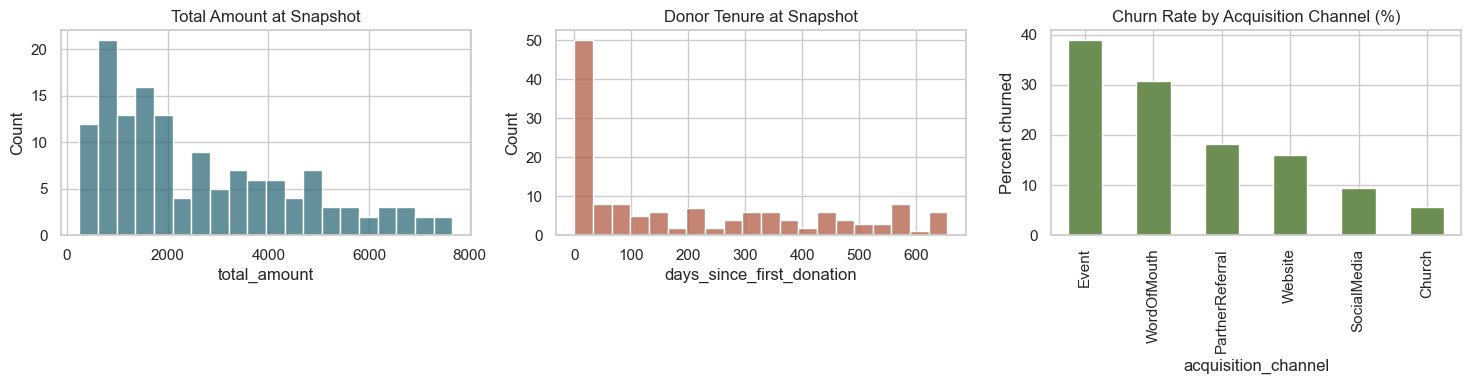

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_model['total_amount'], bins=20, ax=axes[0], color='#2F6B7A')
axes[0].set_title('Total Amount at Snapshot')

sns.histplot(df_model['days_since_first_donation'], bins=20, ax=axes[1], color='#B05C47')
axes[1].set_title('Donor Tenure at Snapshot')

(df_model.groupby('acquisition_channel')['target']
 .mean()
 .sort_values(ascending=False)
 .mul(100)
 .plot(kind='bar', ax=axes[2], color='#6C8E52'))
axes[2].set_title('Churn Rate by Acquisition Channel (%)')
axes[2].set_ylabel('Percent churned')
plt.tight_layout()

summary = (
    df_model.groupby('supporter_type')['target']
    .agg(['count', 'mean'])
    .sort_values('mean', ascending=False)
)
summary


## 3. Modeling & Feature Selection

This is a textbook **predictive** pipeline, so the modeling choices optimize out-of-sample performance rather than interpretability.

### Modeling choices
- `LogisticRegression` baseline for calibrated linear signal
- `GradientBoostingClassifier` for non-linear interactions in RFM-style features
- `RandomForestClassifier` as a second non-linear ensemble baseline

### Textbook alignment
- preprocessing is embedded in a reusable `Pipeline`
- we keep correlated predictors if they improve generalization
- we use a **held-out test split** plus **StratifiedKFold CV** on the training set
- hyperparameters are tuned with **RandomizedSearchCV** rather than ad hoc manual guesses


In [4]:
X = df_model[FEATURE_COLS].copy()
y = df_model['target'].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = build_preprocessor()
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search_results = {}

for name, pipeline, params in candidate_search_spaces(preprocessor):
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=params,
        n_iter=min(10, int(__import__('numpy').prod([len(v) for v in params.values()]))),
        scoring='roc_auc',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42,
        refit=True,
    )
    search.fit(X_train, y_train)

    cv_probs = cross_val_predict(
        search.best_estimator_, X_train, y_train, cv=inner_cv, method='predict_proba', n_jobs=-1
    )[:, 1]

    best_threshold, best_f1 = 0.5, -1.0
    for thr in sorted(set(cv_probs.round(4))):
        preds = (cv_probs >= thr).astype(int)
        score = f1_score(y_train, preds, zero_division=0)
        if score > best_f1:
            best_threshold, best_f1 = float(thr), float(score)

    test_probs = search.best_estimator_.predict_proba(X_test)[:, 1]
    test_preds = (test_probs >= best_threshold).astype(int)
    search_results[name] = {
        'search': search,
        'best_threshold': best_threshold,
        'cv_roc_auc': float(search.best_score_),
        'roc_auc_test': float(roc_auc_score(y_test, test_probs)),
        'f1_test': float(f1_score(y_test, test_preds, zero_division=0)),
        'precision_test': float(precision_score(y_test, test_preds, zero_division=0)),
        'recall_test': float(recall_score(y_test, test_preds, zero_division=0)),
    }

results_table = pd.DataFrame({
    name: {k: v for k, v in result.items() if k != 'search'}
    for name, result in search_results.items()
}).T.sort_values(['roc_auc_test', 'f1_test'], ascending=False)
results_table


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

,best_threshold,cv_roc_auc,roc_auc_test,f1_test,precision_test,recall_test
rf,0.2625,0.807018,0.420290,0.250000,0.200000,0.333333
logreg,0.5060,0.789211,0.398551,0.133333,0.111111,0.166667
gbm,0.4737,0.796053,0.384058,0.000000,0.000000,0.000000


## 4. Evaluation & Interpretation

The most important grading criterion here is **out-of-sample performance**, so model selection is based on the held-out test split after tuning on the training set.

### Business interpretation of errors
- **False positive:** staff spend time trying to retain a donor who was probably going to give again anyway
- **False negative:** the organization misses a donor who then disappears for a year or more

Because false negatives are more expensive, the threshold is tuned from training CV probabilities rather than fixed at `0.50` by default.


Selected model: rf
Threshold: 0.2625
              precision    recall  f1-score   support

           0      0.789     0.652     0.714        23
           1      0.200     0.333     0.250         6

    accuracy                          0.586        29
   macro avg      0.495     0.493     0.482        29
weighted avg      0.668     0.586     0.618        29



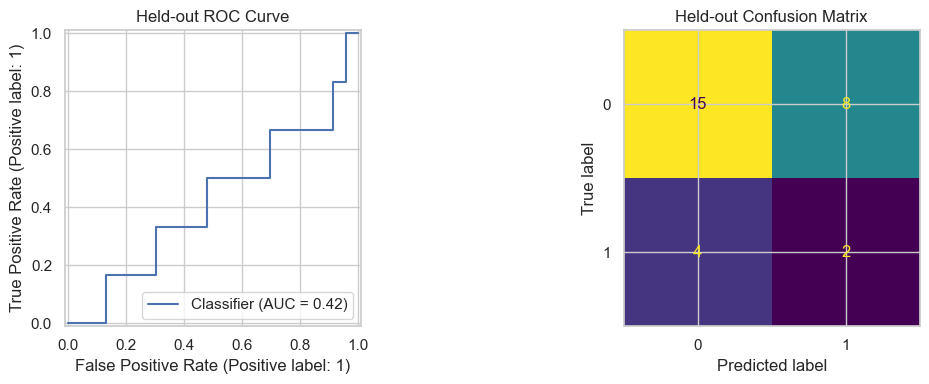

In [5]:
best_name = results_table.index[0]
best_search = search_results[best_name]['search']
best_threshold = search_results[best_name]['best_threshold']
best_model = best_search.best_estimator_

test_probs = best_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

print(f"Selected model: {best_name}")
print(f"Threshold: {best_threshold:.4f}")
print(classification_report(y_test, test_preds, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, test_probs, ax=axes[0])
axes[0].set_title('Held-out ROC Curve')
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, ax=axes[1], colorbar=False)
axes[1].set_title('Held-out Confusion Matrix')
plt.tight_layout()


## 5. Causal and Relationship Analysis

This remains a **predictive** pipeline, so the relationships below are **correlational** rather than causal. Still, permutation importance is useful because it shows which features actually matter to held-out performance.

If recency, recurring-share, or donor tenure rank highly, that does not mean changing those values alone would *cause* retention. It means the model has learned that those variables carry signal about future lapse in this donor base.


,feature,importance
7,avg_amount,0.017971
12,relationship_type,0.015942
4,pct_recurring,0.006667
11,supporter_type,0.005797
5,avg_days_between_donations,0.003188
1,days_since_first_donation,0.000870
0,days_since_last_donation,0.000000
6,total_amount,-0.000290
8,max_amount,-0.001739
2,days_since_joined,-0.003188


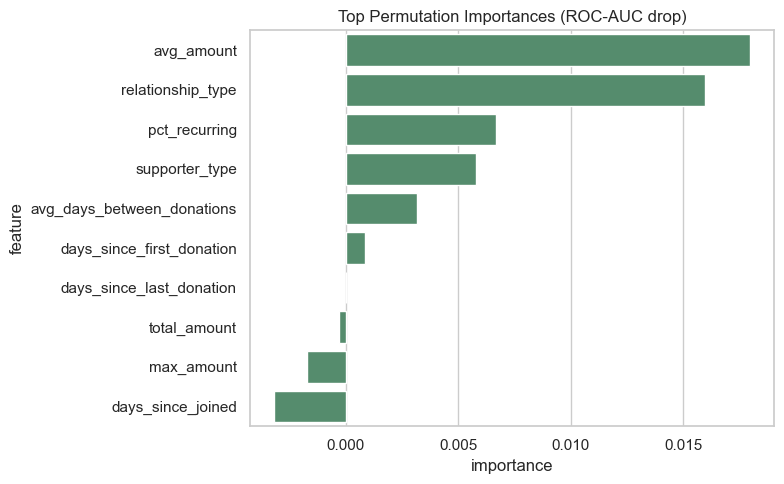

In [6]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=25,
    random_state=42,
    scoring='roc_auc',
)

feature_importance = (
    pd.DataFrame({'feature': FEATURE_COLS, 'importance': perm.importances_mean})
    .sort_values('importance', ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance.head(10), y='feature', x='importance', color='#4C956C')
plt.title('Top Permutation Importances (ROC-AUC drop)')
plt.tight_layout()
feature_importance.head(10)


## 6. Deployment Notes

The trained pipeline is serialized to `ml-pipelines/donor_churn_model.joblib`, and its metadata is written to `ml-pipelines/donor_churn_metadata.json`. The web app consumes it through:
- [DonorChurnController.cs](/Users/lukecarr/Desktop/MassiveFolder/backend/EbanHaven.Api/Controllers/DonorChurnController.cs)
- [app.py](/Users/lukecarr/Desktop/MassiveFolder/ml-pipelines/app.py)
- [AtRiskDonors.tsx](/Users/lukecarr/Desktop/MassiveFolder/frontend/src/components/ml/AtRiskDonors.tsx)

That means the notebook, artifact, API, and dashboard can all stay aligned when the model is retrained.


In [7]:
from retrain_donor_churn_model import MODEL_PATH, METADATA_PATH, NUMERIC_FEATURES, CATEGORICAL_FEATURES
import joblib

final_model = best_model.fit(X, y)
metadata = {
    'model_name': f'donor_churn_{best_name}',
    'model_version': '3.0.0',
    'target': f'no donation in next {TARGET_HORIZON_DAYS} days after observation snapshot',
    'labeling_strategy': 'Historical donor snapshots censored to avoid future-lookahead leakage',
    'feature_columns': FEATURE_COLS,
    'numerical_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'roc_auc_test': round(float(roc_auc_score(y_test, test_probs)), 4),
    'f1_test': round(float(f1_score(y_test, test_preds, zero_division=0)), 4),
    'precision_test': round(float(precision_score(y_test, test_preds, zero_division=0)), 4),
    'recall_test': round(float(recall_score(y_test, test_preds, zero_division=0)), 4),
    'best_threshold': round(float(best_threshold), 4),
    'trained_on': pd.Timestamp.utcnow().strftime('%Y-%m-%d'),
    'currency': 'PHP',
    'n_training_samples': int(len(X_train)),
    'n_test_samples': int(len(X_test)),
    'n_positive_total': int(y.sum()),
    'n_negative_total': int((1 - y).sum()),
    'observation_horizon_days': TARGET_HORIZON_DAYS,
    'cv_strategy': 'StratifiedKFold(5) + RandomizedSearchCV on training set',
    'cv_roc_auc_mean': round(float(search_results[best_name]['cv_roc_auc']), 4),
    'data_source': data_source,
}
joblib.dump(final_model, MODEL_PATH)
METADATA_PATH.write_text(json.dumps(metadata, indent=2))
metadata


{'model_name': 'donor_churn_rf',
 'model_version': '3.0.0',
 'target': 'no donation in next 365 days after observation snapshot',
 'labeling_strategy': 'Historical donor snapshots censored to avoid future-lookahead leakage',
 'feature_columns': ['days_since_last_donation',
  'days_since_first_donation',
  'days_since_joined',
  'total_donations',
  'pct_recurring',
  'avg_days_between_donations',
  'total_amount',
  'avg_amount',
  'max_amount',
  'amount_trend',
  'acquisition_channel',
  'supporter_type',
  'relationship_type'],
 'numerical_features': ['days_since_last_donation',
  'days_since_first_donation',
  'days_since_joined',
  'total_donations',
  'pct_recurring',
  'avg_days_between_donations',
  'total_amount',
  'avg_amount',
  'max_amount',
  'amount_trend'],
 'categorical_features': ['acquisition_channel',
  'supporter_type',
  'relationship_type'],
 'roc_auc_test': 0.4203,
 'f1_test': 0.25,
 'precision_test': 0.2,
 'recall_test': 0.3333,
 'best_threshold': 0.2625,
 'tra